# 04 Linked-Read Inversion Detection
Here, we aggregate the visualizations of all size classes and depth treatments for linked-read simulations.

In [1]:
library(ggplot2)
library(ggpattern)
library(dplyr)
library(ggpubr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




We did the LEVIATHAN stuff initially and decided towards the end of the project to include NAIBR, so this will be a succinct version of the analagous LEVIATHAN assessments. First we need to parse through the outputs and aggregate them, adding any additional important fields.

In [33]:
read_data <- function(size_treatment, depth){
    .depth <- paste("depth",depth, sep = "_")
    truthfile <- paste0("simulated_variants/setup_inversions/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/naibr", size_treatment, .depth, "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/naibr", size_treatment, .depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"
    true_inversions$size <- size_treatment


    sample_inversions <- read.table(samplesfile, header = T)[,c(1:3,5)]
    names(sample_inversions) <- c("sample", "contig", "position_start", "position_end")
    if( nrow(sample_inversions) > 0){
        sample_inversions$size <- size_treatment
    }

    pooled_inversions <- read.table(poolfile, header = T)[,c(1:3,5)]
    names(pooled_inversions) <- c("sample", "contig", "position_start", "position_end")
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- "pooled"
        pooled_inversions$size <- size_treatment
    }
    outdf <- rbind(true_inversions, sample_inversions, pooled_inversions)
    outdf$depth <- depth
    return(outdf)
}

read_all_data <- function(size_treatment){
    depth <- 0.5
    .data <- read_data(size_treatment, depth)    
    for(i in c(2,5,10,20)){
        .data <- rbind(.data, read_data(size_treatment, i))    
    }
    return(.data[,c(4,1,2,3,5,6)])
}

In [37]:
inversions <- read_all_data("medium")[0,]
for(i in c("small", "medium", "large", "xl")){
    inversions <- rbind(inversions, read_all_data(i))
}
head(inversions)
write.csv(inversions, file = "assess_called_sv_naibr/called.inv", quote = F, row.names = F)

,sample,contig,position_start,position_end,size,depth
,<chr>,<chr>,<int>,<dbl>,<chr>,<dbl>
1,simulated_inversions,2L,3193196,3214221,small,0.5
2,simulated_inversions,2L,3940211,3944863,small,0.5
3,simulated_inversions,2L,13024404,13026577,small,0.5
4,simulated_inversions,2L,14845709,14861200,small,0.5
5,simulated_inversions,2L,20107901,20113695,small,0.5
6,simulated_inversions,2R,4328632,4333509,small,0.5


Let's read in the data from the outcomes of the individual size-class assessments and combine them into a single table. Since we'll be comparing this to the long-read data, we should also add a column specifing this is linked-read data and write the entire thing into one file.

In [6]:
lr_inversions <- rbind(
    read.csv("assess_called_sv/small.sv.assessment", header = T),
    read.csv("assess_called_sv/medium.sv.assessment", header = T),
    read.csv("assess_called_sv/large.sv.assessment", header = T),
    read.csv("assess_called_sv/xl.sv.assessment", header = T)
)
lr_inversions$technology <- "linkedread"
if(!file.exists("assess_called_sv/linkedread.sv.assessment")){
    write.csv(lr_inversions, file = "assess_called_sv/linkedread.sv.assessment", row.names = F, quote = F)
}
head(lr_inversions)

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end,technology
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>
1,2L,1,1,0.5,11,small,TRUE,hom,false negative,3193196,3214221,linkedread
2,2L,1,1,2.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread
3,2L,1,1,5.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread
4,2L,1,1,10.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread
5,2L,1,1,20.0,11,small,TRUE,hom,true positive,3193196,3214221,linkedread
6,2L,1,1,0.5,1,small,TRUE,hom,false negative,3193196,3214221,linkedread


### Single-Sample Detection
Let's visualize what detection looked like across all treatments with respect to false/true positive/negative. Here, we facet rows across depths and show all the size treatments across columns.

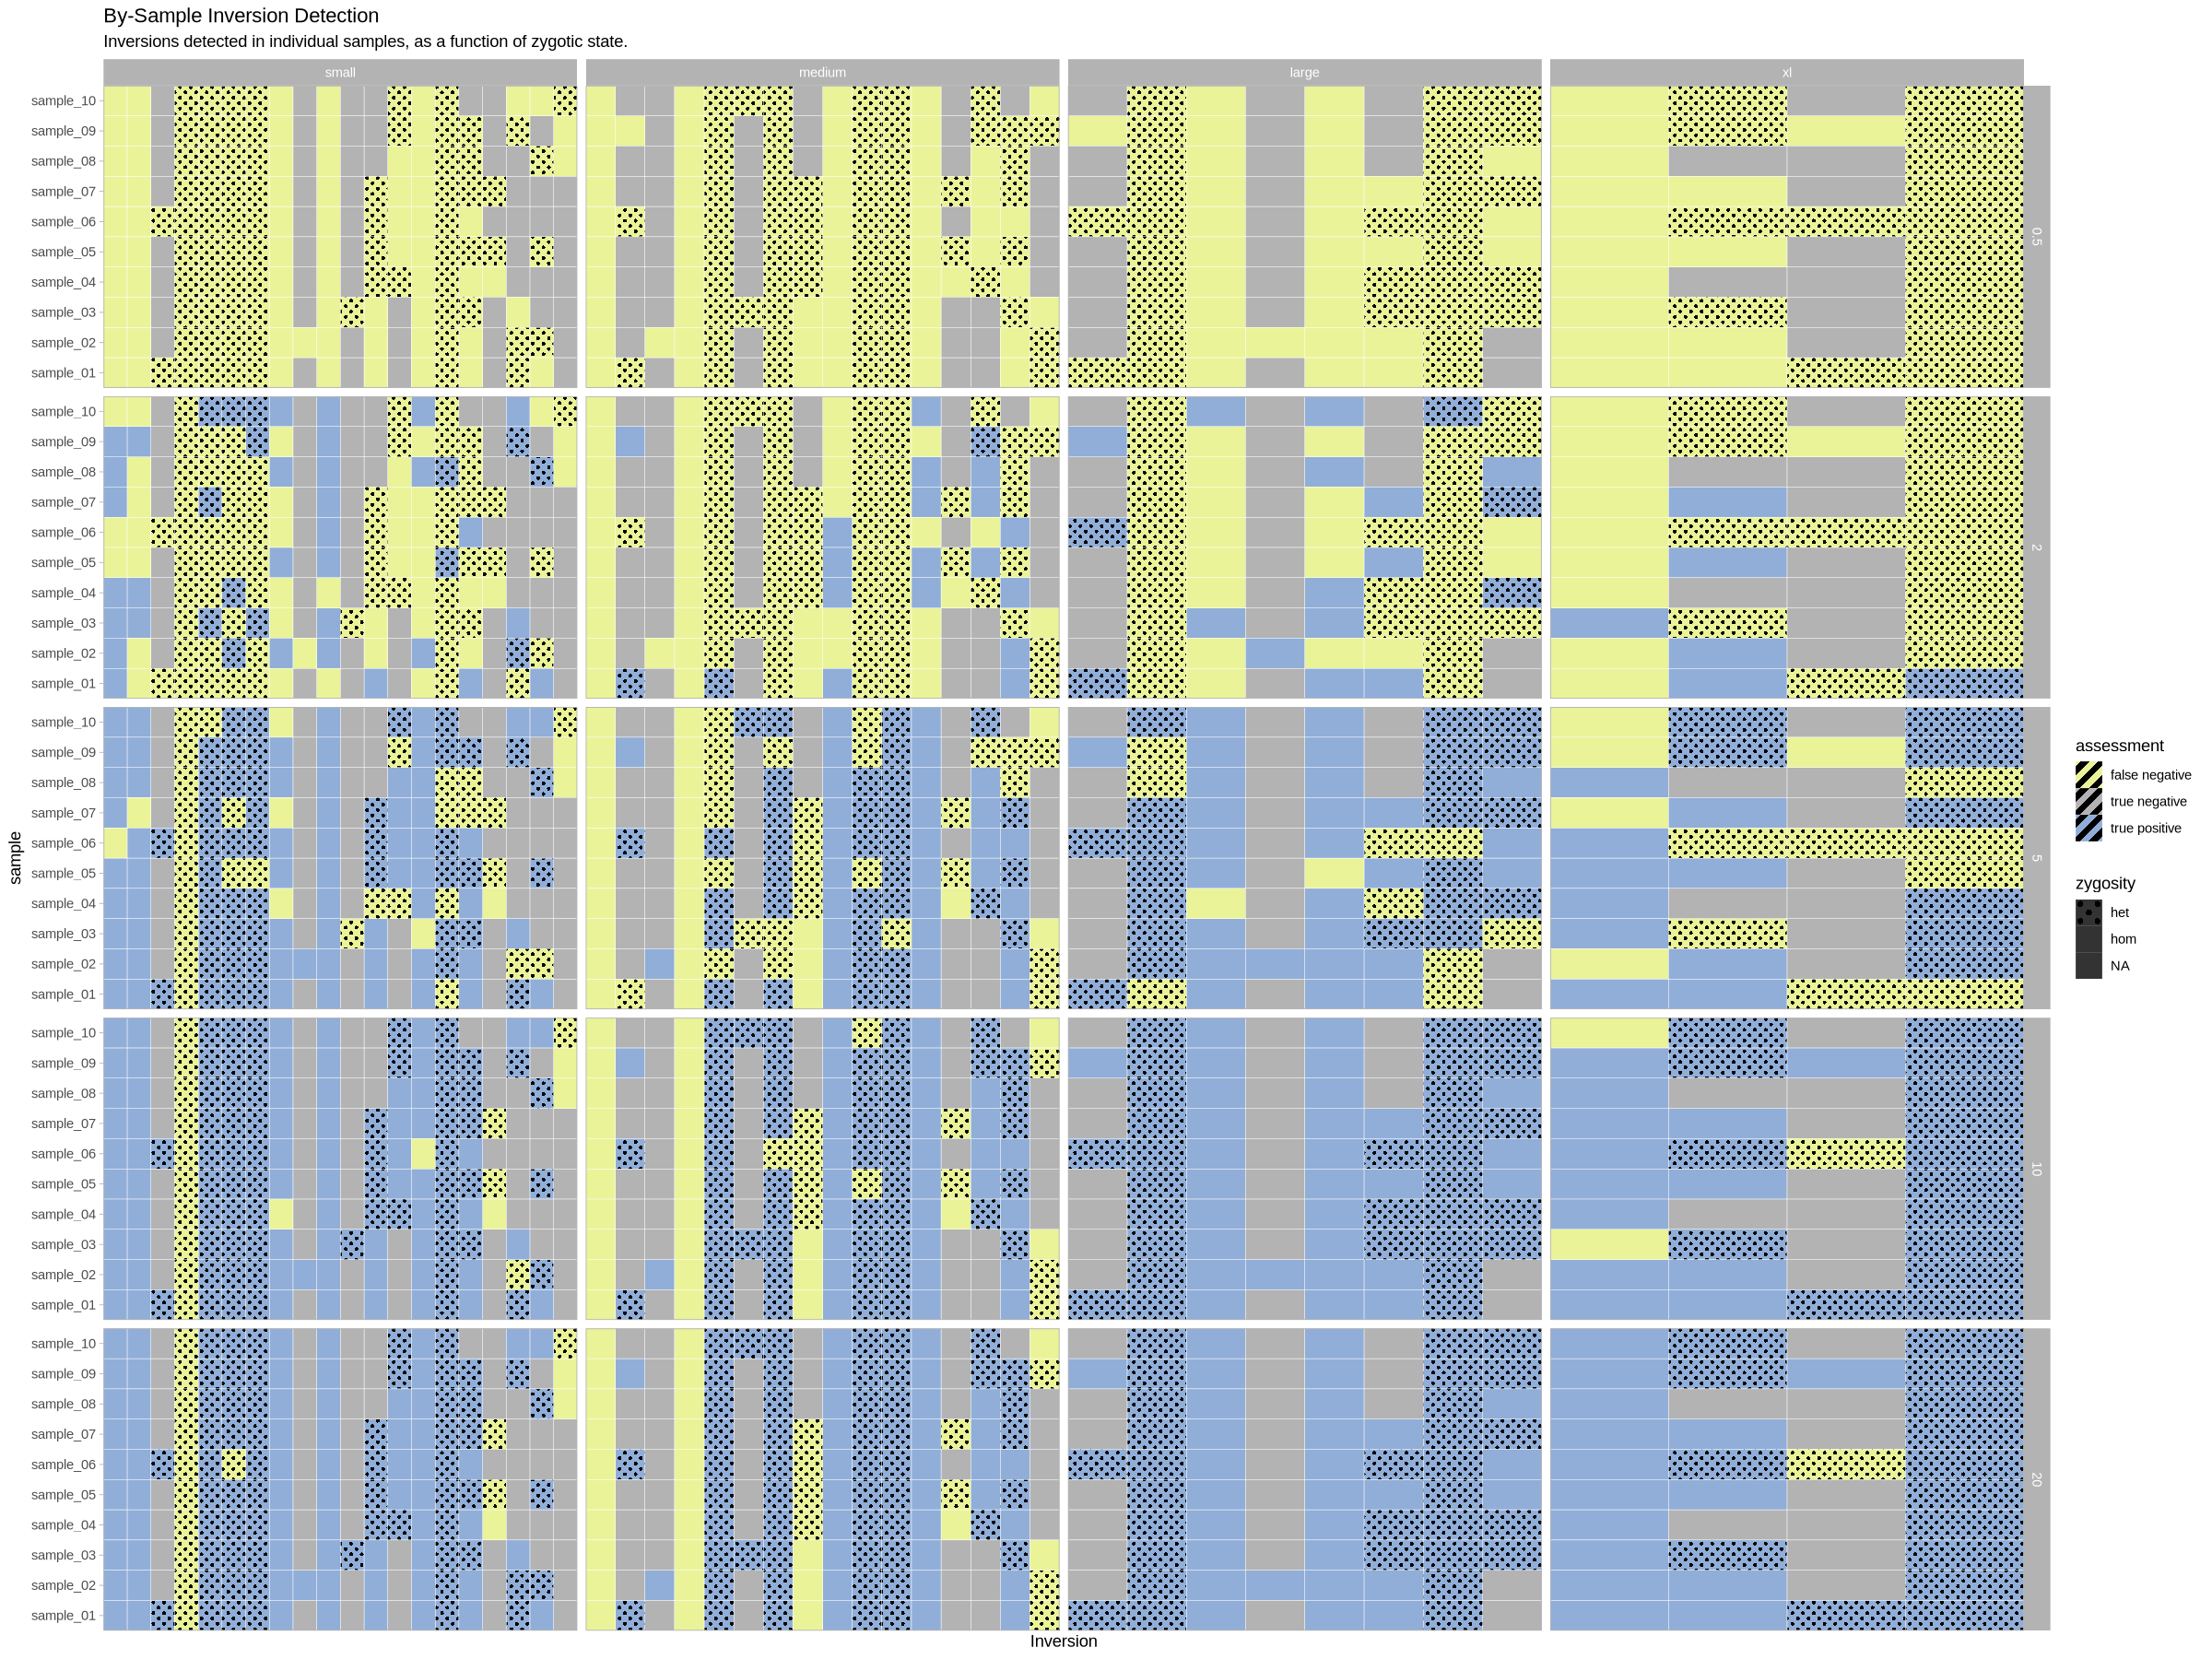

In [17]:
options(warn = -1, repr.plot.width = 20, repr.plot.height = 15)
axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
lr_inversions[lr_inversions$sample != 11,] %>%
    ggplot(aes(y = sample, x = id, fill = assessment, pattern = zygosity)) +
        geom_tile_pattern(
            pattern_color = NA,
            color = "white",
            pattern_fill = "black",
            pattern_angle = 45,
            pattern_density = 0.5,
            pattern_spacing = 0.025,
            pattern_key_scale_factor = 1
        ) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection", subtitle = "Inversions detected in individual samples, as a function of zygotic state.") +
        scale_fill_manual(values = c("false negative" = "#eaf398ff", "true negative" = "grey70", "true positive" = "#90aed8")) +
        scale_pattern_manual(values = c("het" = "circle", "hom" = "none")) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        #coord_cartesian(xlim = c(1, max(lr_inversions$id)), expand = F) +
        coord_cartesian(expand = F) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(depth ~ factor(size, levels = c("small", "medium", "large", "xl")), scales = "free_x")


### Pooled Sample Detection 

In [37]:
plot_pools_matrix <- function(data, size_treatment){
    .data <- data[data$sample == 11 & data$size == size_treatment,]
    .data$contig <- gsub("2L", "2L (all homozygous)", .data$contig)
    .data$contig <- gsub("2R", "2R (all heterozygous)", .data$contig)
    .data$contig <- gsub("3L", "3L (inversions common)", .data$contig)
    .data$contig <- gsub("3R", "3R (inversions rare)", .data$contig)
 
    ggplot(.data, aes(y = 1, x = inversion, fill = assessment)) +
        geom_tile(color = "white", linewidth = 1.5) +
        theme_light() +
        #labs(title = "Pooled-Sample Detection", subtitle = paste(size_treatment, "inversions detected in sample-pooled data, as a function of inversion frequency in the population.")) +
        scale_fill_manual(values = c("false negative" = "grey70", "true positive" = "#90aed8")) +
        scale_y_continuous(breaks = 1, name = "Assessment") +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        ) +
        coord_cartesian(expand = F) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

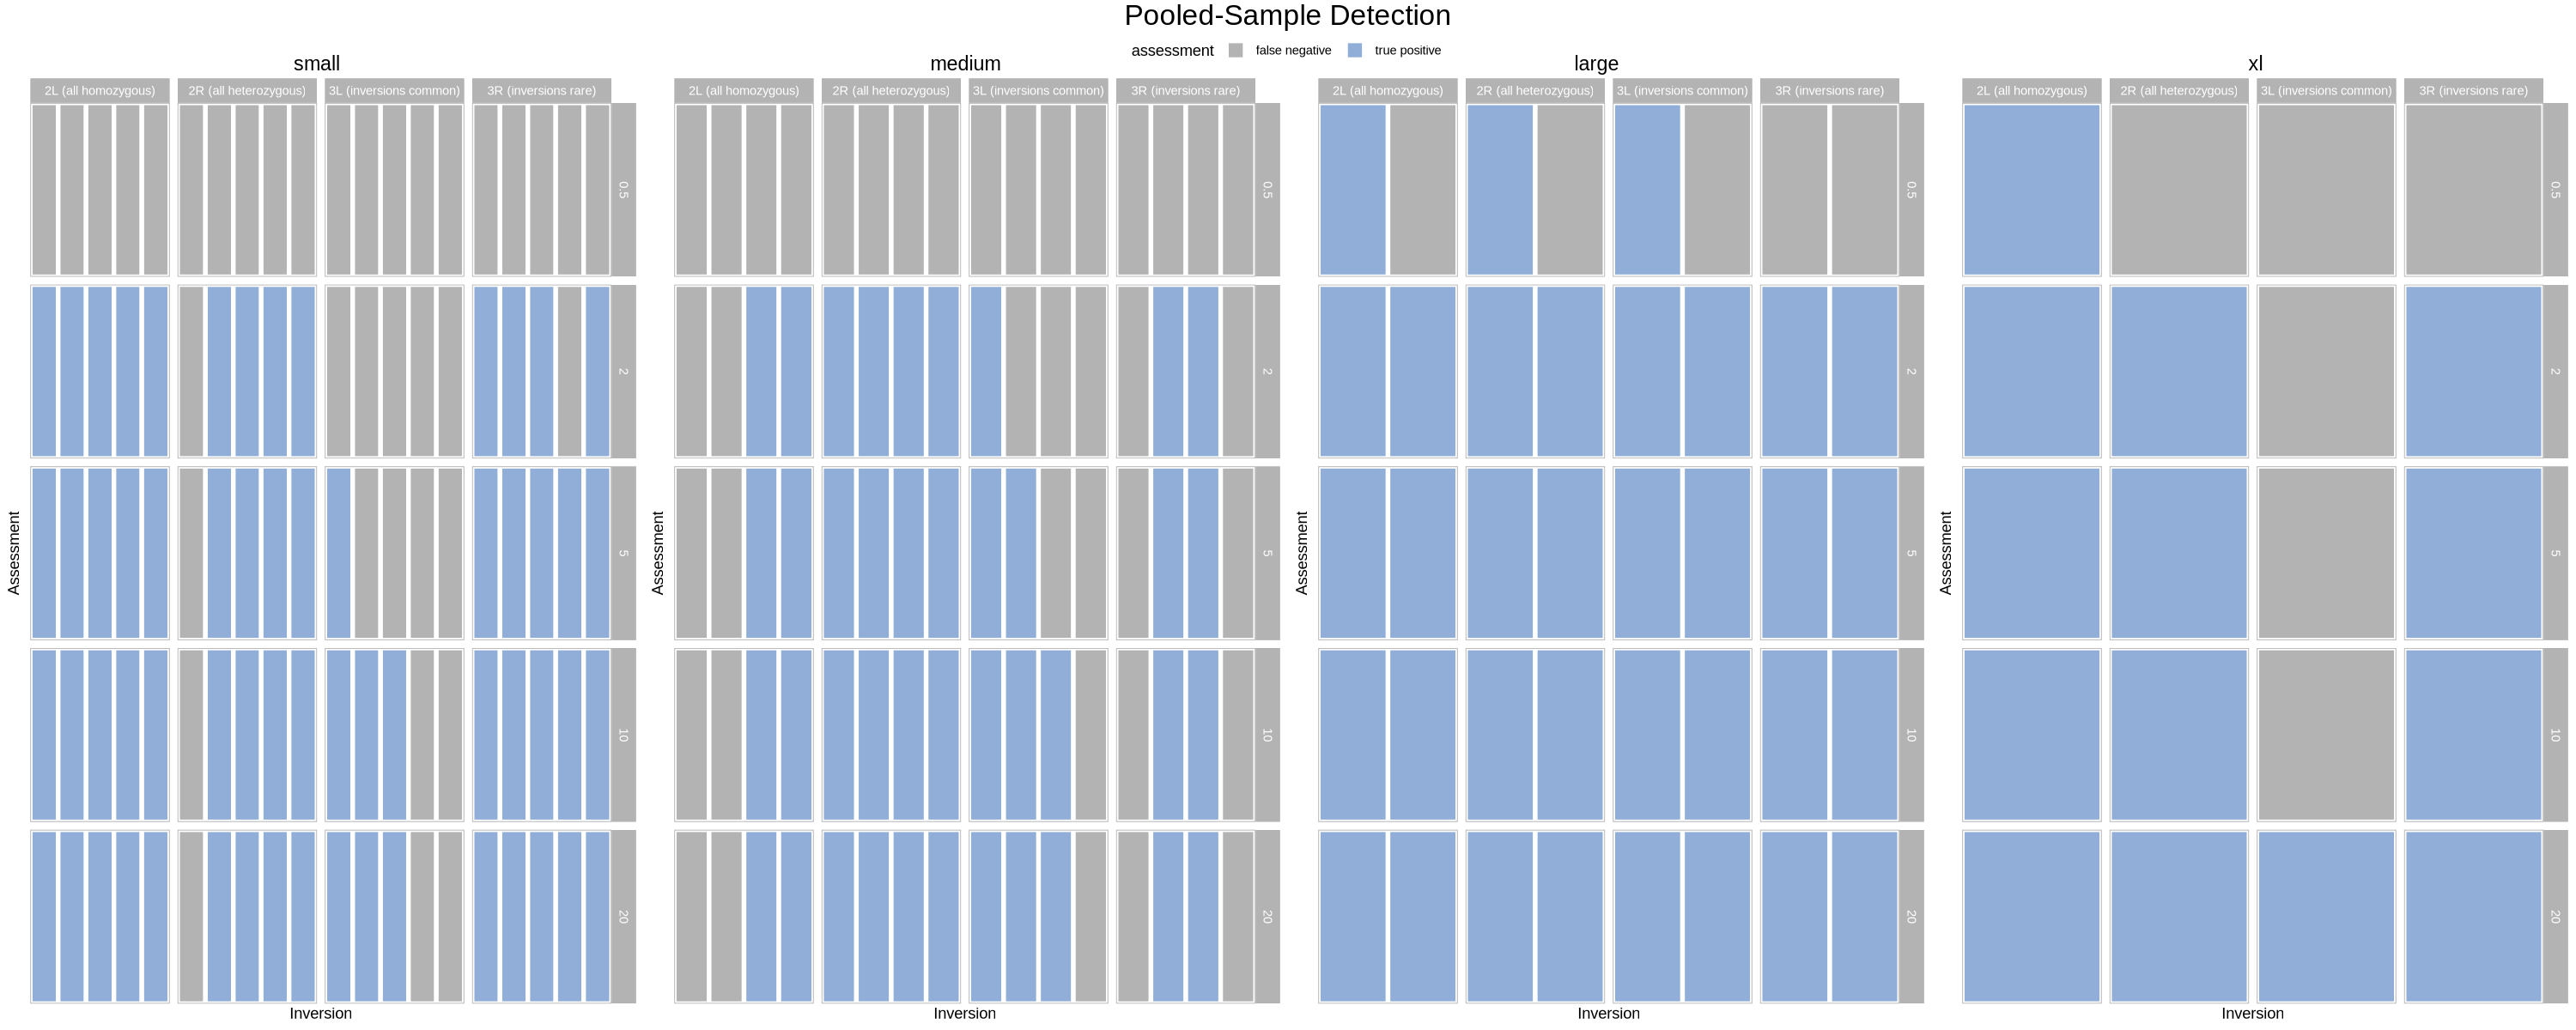

In [66]:
options(warn = -1, repr.plot.width = 25, repr.plot.height = 10)
plot <- ggarrange(
    plot_pools_matrix(lr_inversions, "small"),
    plot_pools_matrix(lr_inversions, "medium"),
    plot_pools_matrix(lr_inversions, "large"),
    plot_pools_matrix(lr_inversions, "xl"),
    labels = c("small", "medium", "large", "xl"),
    nrow = 1, ncol = 4, common.legend = T, font.label = c(face = "plain"), legend = "top", vjust = 0, label.x = c(0.42, 0.39, 0.41, 0.48)
)
annotate_figure(
    plot,
    top = text_grob(
        "Pooled-Sample Detection", color = "black", size = 20
        )
)